# 摘要

本笔记主要讨论了lstm模型在nasa的数据集上的使用情况，是作为深度学习模型的入门模型。

## 第一组电池实验

一组四节锂离子电池（编号为 5、6、7 和 18）在室温下经历了三种不同的运行工况（充电、放电和阻抗测试）。

充电过程采用恒流（CC）模式，以 1.5A 充电，直到电池电压达到 4.2V；随后转为恒压（CV）模式，持续充电直到充电电流下降至 20mA。

放电过程采用恒流（CC）模式，以 2A 的电流进行放电，直到电池电压分别下降至以下截止电压：电池 5 为 2.7V，电池 6 为 2.5V，电池 7 为 2.2V，电池 18 为 2.5V。

阻抗测试通过电化学阻抗谱（EIS）进行，在 0.1Hz 到 5kHz 的频率范围内进行扫描。

反复的充放电循环会加速电池的老化，而阻抗测试能够提供关于电池内部参数的信息，这些参数会随着老化过程而发生变化。

当电池达到寿命终止（EOL）标准时，实验即停止。该标准定义为额定容量衰减 30%（即从 2Ah 下降到 1.4Ah）。

该数据集可用于预测电池在某一放电循环中的剩余电量（Remaining Charge），以及电池的剩余使用寿命（RUL, Remaining Useful Life）。


In [6]:
import os
import pandas as pd

def load_group1_raw_parameters(data_dir):
    """
    加载第一组电池（B0005, B0006, B0007, B0018）的原始放电参数序列。

    读取预处理后的序列化文件，仅隔离放电（discharge）工况，并提取底层的
    物理测量数组（电压、电流、温度、时间）以及容量标签。这些原始参数序列
    将直接作为深度学习模型（如处理时间序列的 LSTM/CNN）的底层输入。

    参数:
    - data_dir (str): 第一组电池预处理后 .pkl 文件所在的目录路径。

    返回:
    - dict: 键为电池 ID（如 'B0005'），值为包含原始参数的 pd.DataFrame。
      DataFrame 包含的列为：
      ['Specific_Index', 'Capacity', 'Voltage_measured', 
       'Current_measured', 'Temperature_measured', 'Time']
    """
    target_batteries = ['B0005', 'B0006', 'B0007', 'B0018']
    raw_parameters_dict = {}
    
    print(f"开始提取第一组电池原始参数，数据目录: {data_dir}")
    
    for battery_id in target_batteries:
        file_path = os.path.join(data_dir, f"{battery_id}.pkl")
        
        if not os.path.exists(file_path):
            print(f"  [警告] 未找到文件: {file_path}")
            continue
            
        try:
            # 1. 载入全量缓存数据
            df_raw = pd.read_pickle(file_path)
            
            # 2. 工况隔离：电池的老化特征（如极化、容量衰减）主要在放电动力学中体现
            df_discharge = df_raw[df_raw['Cycle_Type'] == 'discharge'].copy()
            
            # 3. 维度裁剪：仅保留寿命预测强相关的核心参数列
            # Specific_Index: 相对放电循环次数 (充当时间步基准)
            # Capacity: 当前循环的真实可用容量 (回归目标 Y)
            # Voltage/Current/Temperature/Time: 传感器原始数组 (序列特征 X)
            columns_to_keep = [
                'Specific_Index', 'Capacity', 
                'Voltage_measured', 'Current_measured', 
                'Temperature_measured', 'Time'
            ]
            
            # 过滤因设备故障导致缺少关键参数列的异常数据
            available_columns = [col for col in columns_to_keep if col in df_discharge.columns]
            df_selected = df_discharge[available_columns]
            
            if not df_selected.empty:
                raw_parameters_dict[battery_id] = df_selected
                print(f"  [成功] {battery_id}: 提取了 {len(df_selected)} 个放电循环的原始参数。")
            else:
                print(f"  [失败] {battery_id}: 数据集为空或缺失核心参数。")
                
        except Exception as e:
            print(f"  [异常] 处理 {battery_id} 时发生错误: {e}")
            
    return raw_parameters_dict


# ==========================================
# 模块执行入口
# ==========================================
if __name__ == "__main__":
    # 配置绝对路径（请根据本地环境确认路径正确）
    GROUP1_DIR = r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\1. BatteryAgingARC-FY08Q4"
    
    # 执行参数提取
    group1_parameters = load_group1_raw_parameters(GROUP1_DIR)
    
    # 数据结构校验
    if 'B0005' in group1_parameters:
        df_b0005 = group1_parameters['B0005']
        print("\n[数据校验] B0005 电池原始参数矩阵概览 (前 2 行):")
        
        pd.set_option('display.max_colwidth', 40)
        print(df_b0005.head(2))

开始提取第一组电池原始参数，数据目录: C:\Users\PLUTO\Desktop\battery-rul\data\processed\1. BatteryAgingARC-FY08Q4
  [成功] B0005: 提取了 168 个放电循环的原始参数。
  [成功] B0006: 提取了 168 个放电循环的原始参数。
  [成功] B0007: 提取了 168 个放电循环的原始参数。
  [成功] B0018: 提取了 132 个放电循环的原始参数。

[数据校验] B0005 电池原始参数矩阵概览 (前 2 行):
   Specific_Index  Capacity                         Voltage_measured  \
1               1  1.856487  [4.191491807505295, 4.19074906777610...   
3               2  1.846327  [4.189773213846608, 4.18888138027909...   

                          Current_measured  \
1  [-0.004901589207462691, -0.001478005...   
3  [2.125117981080765e-05, -0.000879471...   

                      Temperature_measured  \
1  [24.330033885570543, 24.325993424022...   
3  [24.697751935729325, 24.685948163596...   

                                      Time  
1  [0.0, 16.781, 35.702999999999996, 53...  
3  [0.0, 16.672, 35.703, 53.828, 71.891...  


### 实验一：单电池训练，单电池测试

这一部分我们采用单独拿出一块电池（比如 B0005），将其前 70% 的循环（早期和中期寿命）作为训练集，后 30% 的循环（晚期寿命）作为测试集的方法进行实验。物理意义是：物理意义：模拟“我们已经监控了这块电池一段时间，现在要预测它未来的衰减轨迹和最终寿命终点”。

In [7]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

def build_lstm_dataloader(df_battery, seq_length=10, train_ratio=0.7, batch_size=16):
    """
    构建用于 LSTM 训练的 PyTorch 数据加载器（针对单块电池的按时间序划分）。

    参数:
    - df_battery (pd.DataFrame): 包含单块电池原始参数的 DataFrame（如 B0005）。
    - seq_length (int): 滑动窗口大小，即使用过去多少次循环来预测下一次循环。
    - train_ratio (float): 训练集所占的生命周期比例（默认前 70% 作为训练集）。
    - batch_size (int): 批处理大小。

    返回:
    - tuple: (train_loader, test_loader, scaler_y)
      scaler_y 用于在预测结束后，将模型输出的归一化值还原回真实的容量值 (Ah)。
    """
    # ==========================================
    # 1. 物理特征降维 (从原始数组中提取标量特征)
    # ==========================================
    features_list = []
    for _, row in df_battery.iterrows():
        try:
            capacity = row['Capacity']
            discharge_time = row['Time'][-1]
            max_temp = np.max(row['Temperature_measured'])
            
            features_list.append([discharge_time, max_temp, capacity])
        except Exception:
            continue
            
    # shape: (N_cycles, 3), 最后一列为目标标签 Capacity
    data_matrix = np.array(features_list)
    
    # ==========================================
    # 2. 时序数据集划分 (Chronological Split)
    # ==========================================
    total_cycles = len(data_matrix)
    train_size = int(total_cycles * train_ratio)
    
    # 前 70% 循环为训练集，后 30% 为测试集
    train_data = data_matrix[:train_size, :]
    test_data = data_matrix[train_size:, :]
    
    # ==========================================
    # 3. 严格的数据归一化 (防止数据泄露)
    # ==========================================
    # 分离特征 (X) 和标签 (Y) 的缩放器，以便后续单独反归一化 Y
    scaler_x = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    # 仅在训练集上拟合 (fit)，在训练和测试集上应用 (transform)
    train_x_scaled = scaler_x.fit_transform(train_data[:, :-1])
    train_y_scaled = scaler_y.fit_transform(train_data[:, -1].reshape(-1, 1))
    
    test_x_scaled = scaler_x.transform(test_data[:, :-1])
    test_y_scaled = scaler_y.transform(test_data[:, -1].reshape(-1, 1))
    
    # 重新拼接以便进行滑动窗口切分
    train_scaled = np.hstack((train_x_scaled, train_y_scaled))
    test_scaled = np.hstack((test_x_scaled, test_y_scaled))
    
    # ==========================================
    # 4. 构造滑动窗口 (Sliding Window)
    # ==========================================
    def create_window(data, seq_len):
        x, y = [], []
        for i in range(len(data) - seq_len):
            # 取当前窗口内的所有特征作为 X
            x.append(data[i : i + seq_len, :-1])
            # 取窗口后一步的容量作为 Y
            y.append(data[i + seq_len, -1])
        return np.array(x), np.array(y).reshape(-1, 1)

    x_train, y_train = create_window(train_scaled, seq_length)
    x_test, y_test = create_window(test_scaled, seq_length)
    
    # ==========================================
    # 5. 张量转换与 DataLoader 封装
    # ==========================================
    train_dataset = TensorDataset(torch.tensor(x_train, dtype=torch.float32), 
                                  torch.tensor(y_train, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(x_test, dtype=torch.float32), 
                                 torch.tensor(y_test, dtype=torch.float32))
    
    # 训练集打乱可提升模型鲁棒性，测试集必须保持时序顺序
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    print(f"数据处理完成:")
    print(f"  训练集张量形状 X: {x_train.shape}, Y: {y_train.shape}")
    print(f"  测试集张量形状 X: {x_test.shape}, Y: {y_test.shape}")
    
    return train_loader, test_loader, scaler_y

简单的两层lstm定义如下（说实话我没有细致的去实现，因为库里面有）

In [8]:
import torch.nn as nn

class BatteryLSTM(nn.Module):
    """
    用于电池剩余使用寿命 (RUL) 预测的标准 LSTM 网络架构。
    """
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
        """
        初始化网络参数。
        
        参数:
        - input_dim (int): 输入特征的维度（例如本例中包含了时间与温度，为 2）。
        - hidden_dim (int): LSTM 隐藏层神经元的数量。
        - num_layers (int): LSTM 堆叠的层数。
        - output_dim (int): 输出维度（预测单点容量，则为 1）。
        - dropout (float): 防止过拟合的 Dropout 比例。
        """
        super(BatteryLSTM, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # 定义 LSTM 层
        # batch_first=True 确保输入张量的第一个维度是 Batch 大小
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # 定义全连接输出层，将 LSTM 的高维特征映射为标量容量预测值
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        """
        定义前向传播逻辑。
        
        参数:
        - x (torch.Tensor): 形状为 (batch_size, seq_length, input_dim) 的输入张量。
        
        返回:
        - out (torch.Tensor): 形状为 (batch_size, output_dim) 的预测值。
        """
        # 初始化隐藏状态 (h0) 和细胞状态 (c0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # LSTM 前向计算
        # out 形状: (batch_size, seq_length, hidden_dim)
        out, _ = self.lstm(x, (h0, c0))
        
        # RUL 预测属于 Sequence-to-One 任务，因此仅提取最后一个时间步的隐状态传递给全连接层
        out = out[:, -1, :]
        out = self.fc(out)
        
        return out

简单的数据清洗与特征工程，特征工程采用了02笔记本中提到的放电时间和最高温度。为何采用这两个作为特征详见：https://www.researchgate.net/publication/340045888_Remaining_Useful_Life_Estimation_of_Lithium-Ion_Batteries_Based_on_Optimal_Time_Series_Health_Indicator

https://pangea.stanford.edu/ERE/pdf/OnoriPDF/Journals/43.pdf

In [9]:
def clean_raw_data(df_raw_params):
    """
    第一阶段：底层数据清洗。
    
    直接操作包含原始传感测量数组的 DataFrame，通过物理阈值与结构完整性校验，
    拦截并剔除因充放电测试仪 (Arbin 电池测试系统) 故障产生的脏数据。
    
    参数:
    - df_raw_params (pd.DataFrame): 包含原始参数数组的数据框。
    
    返回:
    - pd.DataFrame: 清洗后的数据框，去除了结构破损的异常行。
    """
    valid_rows = []
    
    for index, row in df_raw_params.iterrows():
        try:
            capacity = row['Capacity']
            time_arr = row['Time']
            temp_arr = row['Temperature_measured']
            
            # 规则 1: 物理悖论校验
            # 真实容量不可能小于等于 0；放电过程的记录时间序列不能为空
            if capacity <= 0 or len(time_arr) == 0 or len(temp_arr) == 0:
                continue
                
            # 规则 2: 数据结构校验
            # 确认底层的 numpy 数组没有发生类型突变 (Type Mutation)
            if not isinstance(time_arr, np.ndarray) or not isinstance(temp_arr, np.ndarray):
                continue
                
            # 规则 3: 测量异常值校验
            # 如果传感器记录了绝对零度以下的物理不可能温度，判定该次循环传感器失效
            if np.min(temp_arr) < -50:
                continue
                
            valid_rows.append(row)
            
        except (KeyError, IndexError, TypeError):
            # 拦截由于字段缺失引发的代码级异常
            continue
            
    df_cleaned = pd.DataFrame(valid_rows)
    # 强制重置索引，保证后续切片的连续性
    df_cleaned.reset_index(drop=True, inplace=True)
    
    return df_cleaned

In [10]:
def extract_health_indicators(df_cleaned):
    """
    第二阶段：健康因子 (HIs) 特征提炼。
    
    从已经过严格清洗的原始测量数组中，计算表征电池老化规律的核心物理量。
    
    参数:
    - df_cleaned (pd.DataFrame): 经过 clean_raw_data 处理后的数据框。
    
    返回:
    - pd.DataFrame: 仅包含标量特征与标签的二维特征矩阵，
      列名为 ['Cycle', 'Capacity', 'Discharge_Time', 'Max_Temp']。
    """
    features = []
    
    for _, row in df_cleaned.iterrows():
        # 此时可以绝对安全地进行索引与聚合计算，无需再套用冗余的 try...except
        time_arr = row['Time']
        temp_arr = row['Temperature_measured']
        
        # 提取恒流放电耗时
        discharge_time = time_arr[-1]
        
        # 提取极化最高温度：映射内阻增加带来的焦耳热效应
        max_temp = np.max(temp_arr)
        
        features.append({
            'Cycle': row['Specific_Index'],
            'Capacity': row['Capacity'],           # 回归目标 (Y)
            'Discharge_Time': discharge_time,      # 输入特征 (X1)
            'Max_Temp': max_temp                   # 输入特征 (X2)
        })
        
    return pd.DataFrame(features)

接下来开始数据清洗的部分，我们使用：$$x' = \frac{x - \min}{\max - \min}$$ 进行缩放

In [11]:
def split_and_scale_features(df_features, train_ratio=0.7):
    """
    按时间序列划分数据集，并执行严格防泄露的 Min-Max 归一化。
    
    物理逻辑：
    - 神经网络对输入特征的量级高度敏感，必须将耗时(秒)与温度(摄氏度)统一映射至 [0, 1] 区间。
    - 保持时间序列的绝对顺序进行切分，模拟真实的“由过去预测未来”场景。
    
    参数:
    - df_features (pd.DataFrame): 提取清洗后的特征矩阵，
      需包含 ['Discharge_Time', 'Max_Temp', 'Capacity'] 等列。
    - train_ratio (float): 训练集所占生命周期的比例（默认 0.7）。
    
    返回:
    - tuple: (X_train_scaled, Y_train_scaled, X_test_scaled, Y_test_scaled, scaler_y)
      返回归一化后的 Numpy 数组，以及独立的 Y 缩放器（后续用于反归一化还原真实容量）。
    """
    # 1. 定义特征矩阵 (X) 与目标标签 (Y)
    # X 包含放电时长与最高温度，Y 为当前剩余容量
    feature_cols = ['Discharge_Time', 'Max_Temp']
    target_col = ['Capacity']
    
    X_data = df_features[feature_cols].values
    Y_data = df_features[target_col].values
    
    # 2. 时序集切分 (Chronological Split)
    # 绝对不能使用随机打乱 (shuffle)，必须按生命周期切断
    total_samples = len(df_features)
    train_size = int(total_samples * train_ratio)
    
    X_train, X_test = X_data[:train_size], X_data[train_size:]
    Y_train, Y_test = Y_data[:train_size], Y_data[train_size:]
    
    # 3. 实例化独立的缩放器
    # 为什么 X 和 Y 要分开？因为预测阶段模型只输出 Y 的归一化值，我们需要用独立的 scaler_y 将其还原
    scaler_x = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    # 4. 执行防泄露的缩放转换
    # 仅在训练集上寻找 Min 和 Max (fit_transform)
    X_train_scaled = scaler_x.fit_transform(X_train)
    Y_train_scaled = scaler_y.fit_transform(Y_train)
    
    # 测试集仅使用训练集的 Min 和 Max 进行映射 (transform)
    X_test_scaled = scaler_x.transform(X_test)
    Y_test_scaled = scaler_y.transform(Y_test)
    
    return X_train_scaled, Y_train_scaled, X_test_scaled, Y_test_scaled, scaler_y

第一阶段：拟合记忆 (fit)
当你调用 scaler_y.fit(Y_train) 时，这台机器才会真正去“看”你的训练集容量数据。
它会在内部默默记下两个参数：

数据最小值 (Min)：比如训练集里测到的最低容量是 1.3 Ah。

数据最大值 (Max)：比如测到的最高容量是 2.0 Ah。
一旦记下，这两个数字就死死烙印在 scaler_y 这个对象里了。

第二阶段：正向压缩 (transform)
紧接着调用 scaler_y.transform(Y_train)，机器就会利用刚才记下的参数，把 1.3 ~ 2.0 Ah 之间的真实容量，映射成 0 ~ 1 之间的小数（比如 1.65 Ah 会被转换成 0.5）。这个转换后的小数，才是真正喂给 LSTM 网络的标签。

第三阶段：反向还原 (inverse_transform)
这是我们为什么必须为 Y（容量标签）单独创建一个缩放器的根本原因！

等你的 LSTM 模型训练好之后，模型对未来进行预测，吐出来的结果也会是 0 到 1 之间的小数（比如预测输出是 0.42）。

这个 0.42 对人类工程师来说是没有物理意义的。这时候，我们就会再次请出 scaler_y，调用它的反向还原功能：
真实容量 = scaler_y.inverse_transform([[0.42]])

数据处理完成:
  训练集张量形状 X: (107, 10, 2), Y: (107, 1)
  测试集张量形状 X: (41, 10, 2), Y: (41, 1)

开始执行 LSTM 训练过程...
Epoch [30/150], Loss: 0.002560
Epoch [60/150], Loss: 0.002374
Epoch [90/150], Loss: 0.002241
Epoch [120/150], Loss: 0.002311
Epoch [150/150], Loss: 0.001816


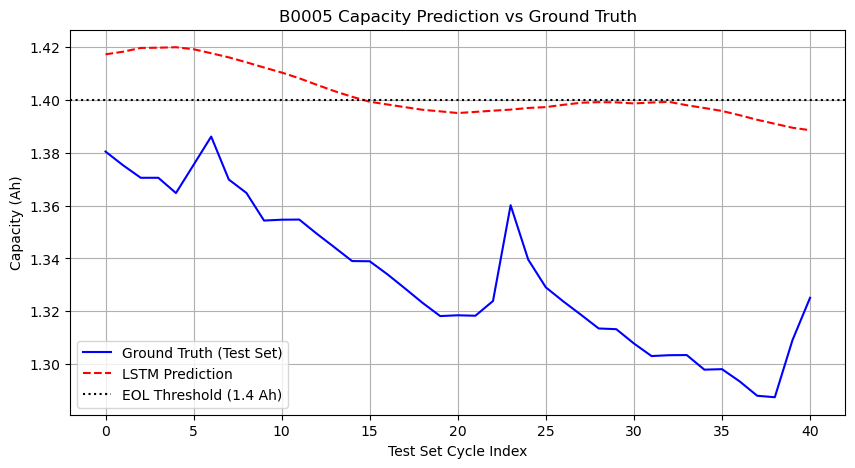

In [12]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ==========================================
# 1. 调度 DataLoader 与模型实例化
# ==========================================
# 提取 B0005 数据
df_b0005 = group1_parameters['B0005']

# 使用已定义的预处理管道构建张量迭代器
# 返回的输入特征维度固定为 2 (Discharge_Time, Max_Temp)
SEQ_LENGTH = 10
train_loader, test_loader, scaler_y = build_lstm_dataloader(
    df_b0005, seq_length=SEQ_LENGTH, train_ratio=0.7, batch_size=16
)

# 实例化已定义的 LSTM 架构
model = BatteryLSTM(input_dim=2, hidden_dim=64, num_layers=2, output_dim=1)

# 定义损失函数与优化器
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 150

# ==========================================
# 2. 核心训练循环 (Training Loop)
# ==========================================
print("\n开始执行 LSTM 训练过程...")
train_loss_history = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        
        # 前向传播
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        # 反向传播与优化
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_loss_history.append(avg_loss)
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.6f}")

# ==========================================
# 3. 测试集评估与反归一化 (Evaluation)
# ==========================================
model.eval()
predictions_list = []
actuals_list = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        predictions_list.append(outputs.item())
        actuals_list.append(batch_y.item())

# 使用先前保存的 scaler_y 将 [0, 1] 的预测值还原为真实的 Ah 容量
import numpy as np
predictions_real = scaler_y.inverse_transform(np.array(predictions_list).reshape(-1, 1))
actuals_real = scaler_y.inverse_transform(np.array(actuals_list).reshape(-1, 1))

# ==========================================
# 4. 可视化结果 (Visualization)
# ==========================================
plt.figure(figsize=(10, 5))

# 绘制验证集对比曲线
plt.plot(actuals_real, label='Ground Truth (Test Set)', color='blue')
plt.plot(predictions_real, label='LSTM Prediction', color='red', linestyle='--')

# 绘制失效阈值线 (EOL)
plt.axhline(y=1.4, color='black', linestyle=':', label='EOL Threshold (1.4 Ah)')

plt.title('B0005 Capacity Prediction vs Ground Truth')
plt.xlabel('Test Set Cycle Index')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.grid(True)
plt.show()

这个结果并不够理想，因为我们可以看到lstm似乎很迟疑，因为实际上的电池下降的很快。但是lstm却不敢往下走，这可能是因为lstm没有看过完整的电池生命周期。

## 实验二：多电池训练，单电池测试

本次实验采用多块电池b0005,b0006,b0007作为训练集，让b0018作为测试集来进行实验。

In [13]:
def build_cross_battery_dataloader(parameters_dict, train_ids, test_ids, seq_length=10, batch_size=16):
    """
    构建跨电池评估 (Inter-battery Evaluation) 的严谨数据管道。
    
    处理逻辑：
    1. 提取所有目标电池的标量特征。
    2. 汇总所有训练集电池的数据，统一拟合 Min-Max 缩放器，确立全局物理特征边界。
    3. 逐个电池进行归一化与滑动窗口切分，绝对避免跨电池的时序缝合污染。
    4. 将切分后的合法张量在 Batch 维度进行堆叠拼接。
    
    返回:
    - train_loader, test_loader, scaler_y, test_actual_capacity (用于绘图对比)
    """
    # 内部辅助函数：清洗与特征提取
    def extract_features(df_raw):
        features = []
        for _, row in df_raw.iterrows():
            try:
                cap = row['Capacity']
                time_arr = row['Time']
                temp_arr = row['Temperature_measured']
                if cap > 0 and len(time_arr) > 0:
                    features.append([time_arr[-1], np.max(temp_arr), cap])
            except Exception:
                continue
        return np.array(features)

    # 1. 提取各个电池的纯净特征矩阵
    feature_matrices = {}
    for b_id in train_ids + test_ids:
        feature_matrices[b_id] = extract_features(parameters_dict[b_id])
        
    # 2. 构建全局训练集缩放器 (仅在 train_ids 包含的数据上 fit)
    train_concat = np.vstack([feature_matrices[b_id] for b_id in train_ids])
    
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    # 训练集特征 X (放电时间, 最高温度) 与 标签 Y (容量)
    scaler_x.fit(train_concat[:, :-1])
    scaler_y.fit(train_concat[:, -1].reshape(-1, 1))
    
    # 内部辅助函数：执行归一化与窗口切分
    def process_single_battery(matrix, is_test=False):
        x_scaled = scaler_x.transform(matrix[:, :-1])
        y_scaled = scaler_y.transform(matrix[:, -1].reshape(-1, 1))
        
        x_seq, y_seq = [], []
        for i in range(len(matrix) - seq_length):
            x_seq.append(x_scaled[i : i + seq_length])
            y_seq.append(y_scaled[i + seq_length])
            
        return np.array(x_seq), np.array(y_seq)

    # 3. 逐个处理训练集电池并聚合张量
    X_train_list, Y_train_list = [], []
    for b_id in train_ids:
        x_seq, y_seq = process_single_battery(feature_matrices[b_id])
        X_train_list.append(x_seq)
        Y_train_list.append(y_seq)
        
    X_train_tensor = torch.tensor(np.vstack(X_train_list), dtype=torch.float32)
    Y_train_tensor = torch.tensor(np.vstack(Y_train_list), dtype=torch.float32)
    
    # 4. 处理测试集电池 (假设仅一个测试电池，如 B0018)
    test_id = test_ids[0]
    X_test, Y_test = process_single_battery(feature_matrices[test_id])
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)
    
    # 5. 封装 DataLoader
    train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    print(f"数据管道构建完成:")
    print(f"  全局训练集张量 (B0005, B0006, B0007): X={X_train_tensor.shape}, Y={Y_train_tensor.shape}")
    print(f"  独立测试集张量 (B0018): X={X_test_tensor.shape}, Y={Y_test_tensor.shape}")
    
    # 提取测试集全部原始容量用于最终绘图参照
    test_actual_capacity = feature_matrices[test_id][:, -1]
    
    return train_loader, test_loader, scaler_y, test_actual_capacity


数据管道构建完成:
  全局训练集张量 (B0005, B0006, B0007): X=torch.Size([474, 10, 2]), Y=torch.Size([474, 1])
  独立测试集张量 (B0018): X=torch.Size([122, 10, 2]), Y=torch.Size([122, 1])
Epoch [30/150], Loss: 0.006010
Epoch [60/150], Loss: 0.004955
Epoch [90/150], Loss: 0.004755
Epoch [120/150], Loss: 0.004369
Epoch [150/150], Loss: 0.004577


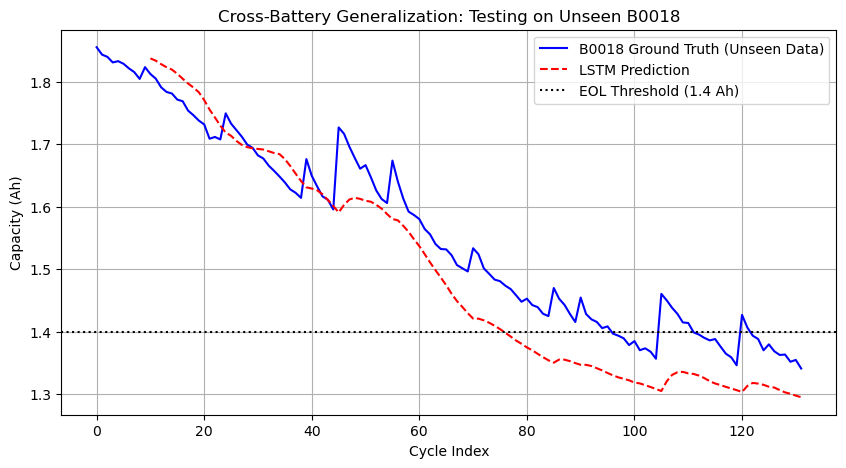

In [14]:

import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

def build_cross_battery_dataloader(parameters_dict, train_ids, test_ids, seq_length=10, batch_size=16):
    """
    构建跨电池评估 (Inter-battery Evaluation) 的严谨数据管道。
    
    处理逻辑：
    1. 提取所有目标电池的标量特征。
    2. 汇总所有训练集电池的数据，统一拟合 Min-Max 缩放器，确立全局物理特征边界。
    3. 逐个电池进行归一化与滑动窗口切分，绝对避免跨电池的时序缝合污染。
    4. 将切分后的合法张量在 Batch 维度进行堆叠拼接。
    
    返回:
    - train_loader, test_loader, scaler_y, test_actual_capacity (用于绘图对比)
    """
    # 内部辅助函数：清洗与特征提取
    def extract_features(df_raw):
        features = []
        for _, row in df_raw.iterrows():
            try:
                cap = row['Capacity']
                time_arr = row['Time']
                temp_arr = row['Temperature_measured']
                if cap > 0 and len(time_arr) > 0:
                    features.append([time_arr[-1], np.max(temp_arr), cap])
            except Exception:
                continue
        return np.array(features)

    # 1. 提取各个电池的纯净特征矩阵
    feature_matrices = {}
    for b_id in train_ids + test_ids:
        feature_matrices[b_id] = extract_features(parameters_dict[b_id])
        
    # 2. 构建全局训练集缩放器 (仅在 train_ids 包含的数据上 fit)
    train_concat = np.vstack([feature_matrices[b_id] for b_id in train_ids])
    
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    # 训练集特征 X (放电时间, 最高温度) 与 标签 Y (容量)
    scaler_x.fit(train_concat[:, :-1])
    scaler_y.fit(train_concat[:, -1].reshape(-1, 1))
    
    # 内部辅助函数：执行归一化与窗口切分
    def process_single_battery(matrix, is_test=False):
        x_scaled = scaler_x.transform(matrix[:, :-1])
        y_scaled = scaler_y.transform(matrix[:, -1].reshape(-1, 1))
        
        x_seq, y_seq = [], []
        for i in range(len(matrix) - seq_length):
            x_seq.append(x_scaled[i : i + seq_length])
            y_seq.append(y_scaled[i + seq_length])
            
        return np.array(x_seq), np.array(y_seq)

    # 3. 逐个处理训练集电池并聚合张量
    X_train_list, Y_train_list = [], []
    for b_id in train_ids:
        x_seq, y_seq = process_single_battery(feature_matrices[b_id])
        X_train_list.append(x_seq)
        Y_train_list.append(y_seq)
        
    X_train_tensor = torch.tensor(np.vstack(X_train_list), dtype=torch.float32)
    Y_train_tensor = torch.tensor(np.vstack(Y_train_list), dtype=torch.float32)
    
    # 4. 处理测试集电池 (假设仅一个测试电池，如 B0018)
    test_id = test_ids[0]
    X_test, Y_test = process_single_battery(feature_matrices[test_id])
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)
    
    # 5. 封装 DataLoader
    train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    print(f"数据管道构建完成:")
    print(f"  全局训练集张量 (B0005, B0006, B0007): X={X_train_tensor.shape}, Y={Y_train_tensor.shape}")
    print(f"  独立测试集张量 (B0018): X={X_test_tensor.shape}, Y={Y_test_tensor.shape}")
    
    # 提取测试集全部原始容量用于最终绘图参照
    test_actual_capacity = feature_matrices[test_id][:, -1]
    
    return train_loader, test_loader, scaler_y, test_actual_capacity
TRAIN_BATTERIES = ['B0005', 'B0006', 'B0007']
TEST_BATTERIES = ['B0018']
SEQ_LENGTH = 10

train_loader, test_loader, scaler_y, all_capacity_b0018 = build_cross_battery_dataloader(
    group1_parameters, TRAIN_BATTERIES, TEST_BATTERIES, seq_length=SEQ_LENGTH
)

model = BatteryLSTM(input_dim=2, hidden_dim=128, num_layers=2, output_dim=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 150

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    if (epoch + 1) % 30 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss/len(train_loader):.6f}")

model.eval()
predictions = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        outputs = model(batch_x)
        predictions.append(outputs.item())

predictions_real = scaler_y.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

plt.figure(figsize=(10, 5))

# 绘制 B0018 完整的真实衰减曲线
plt.plot(range(len(all_capacity_b0018)), all_capacity_b0018, 
         label='B0018 Ground Truth (Unseen Data)', color='blue')

# 绘制预测曲线 (注意 x 轴需要加上序列窗口的偏移量)
predict_x_axis = range(SEQ_LENGTH, len(all_capacity_b0018))
plt.plot(predict_x_axis, predictions_real, 
         label='LSTM Prediction', color='red', linestyle='--')

plt.axhline(y=1.4, color='black', linestyle=':', label='EOL Threshold (1.4 Ah)')

plt.title('Cross-Battery Generalization: Testing on Unseen B0018')
plt.xlabel('Cycle Index')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 计算与实际长度对齐的预测值和真实值
# 注意：前 SEQ_LENGTH (10) 个循环是没有预测值的，需要截断真实值
y_true = all_capacity_b0018[SEQ_LENGTH:]
y_pred = predictions_real

# 计算评估指标
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("====== B0018 测试集量化评估报告 ======")
print(f"均方根误差 (RMSE): {rmse:.4f} Ah")
print(f"平均绝对误差 (MAE): {mae:.4f} Ah")
print(f"平均绝对百分比误差 (MAPE): {mape:.2f}%")

====== B0018 测试集量化评估报告 ======
均方根误差 (RMSE): 0.0642 Ah
平均绝对误差 (MAE): 0.0571 Ah
平均绝对百分比误差 (MAPE): 3.83%


从图像中不难看出：lstm对于室温下的电池剩余寿命预测具有良好的性能。实际上这只是一个简单的toy模型而已，但却取得了良好的效果。

接下来，我们想看看在复杂工况下，这个模型是否具有良好的泛化能力。所以，我们选择B0056号电池。该组由四个锂离子电池（#53–56）组成的电池在 **4°C 的环境温度** 下进行了三种不同运行工况的测试，包括充电、放电以及阻抗测量。充电过程首先采用 **恒流（CC）模式**，以 **1.5A** 的电流进行充电，直到电池电压达到 **4.2V**；随后转入 **恒压（CV）模式**，并持续充电，直到充电电流下降至 **20mA** 为止。

在放电测试中，实验使用了 **2A 的固定负载电流**。不同电池的放电终止电压分别为：电池 **53** 的截止电压为 **2V**，电池 **54** 为 **2.2V**，电池 **55** 为 **2.5V**，电池 **56** 为 **2.7V**。此外，实验还进行了阻抗测量，通过 **电化学阻抗谱（EIS）** 方法，在 **0.1Hz 至 5kHz** 的频率范围内进行频率扫描。

整个实验持续进行，直到电池容量下降至 **1.4Ah**（即容量衰减 **30%**）为止。需要注意的是，在部分放电实验中测得的容量非常低，其具体原因目前尚未得到充分分析。


重构部分代码加载原始数据

In [3]:
import os
import pandas as pd

def load_battery_raw_parameters(data_dir, target_batteries):
    """
    通用电池原始放电参数加载器。
    
    能够动态接收任意电池 ID 列表，提取指定的放电工况底层数组，
    为后续的多工况特征融合（Feature Fusion）提供纯净的原始数据源。

    参数:
    - data_dir (str): 预处理后 .pkl 文件所在的根目录路径。
    - target_batteries (list): 需要加载的电池 ID 列表，例如 ['B0053', 'B0054']。

    返回:
    - dict: 键为电池 ID，值为包含原始放电参数的 pd.DataFrame。
    """
    raw_parameters_dict = {}
    for battery_id in target_batteries:
        file_path = os.path.join(data_dir, f"{battery_id}.pkl")
        
        if not os.path.exists(file_path):
            print(f"  [跳过] 未找到文件: {file_path}")
            continue
            
        try:
            # 1. 载入缓存数据
            df_raw = pd.read_pickle(file_path)
            
            # 2. 工况隔离：仅提取放电数据
            if 'Cycle_Type' in df_raw.columns:
                df_discharge = df_raw[df_raw['Cycle_Type'] == 'discharge'].copy()
            else:
                print(f"  [警告] {battery_id} 缺失 Cycle_Type 列，假定全为放电工况。")
                df_discharge = df_raw.copy()
            
            # 3. 维度裁剪：保留序列特征与回归目标
            columns_to_keep = [
                'Specific_Index', 'Capacity', 
                'Voltage_measured', 'Current_measured', 
                'Temperature_measured', 'Time'
            ]
            
            available_columns = [col for col in columns_to_keep if col in df_discharge.columns]
            df_selected = df_discharge[available_columns]
            
            if not df_selected.empty:
                raw_parameters_dict[battery_id] = df_selected
                print(f"  [成功] 提取 {battery_id} : 共 {len(df_selected)} 个放电循环。")
            else:
                print(f"  [失败] {battery_id} : 数据集为空或缺失核心参数。")
                
        except Exception as e:
            print(f"  [异常] 处理 {battery_id} 时发生系统级错误: {e}")
            
    print(f"加载完成，共成功提取 {len(raw_parameters_dict)} 块电池数据。\n")
    return raw_parameters_dict

In [4]:
# ==========================================
# 灵活调度不同工况的数据集
# ==========================================
# 请替换为你本地实际存放 pkl 的路径
DATA_DIR_group1 = r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\1. BatteryAgingARC-FY08Q4"
DATA_DIR_group6 = r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\6. BatteryAgingARC_53_54_55_56"
# 1. 加载室温数据 (24°C)
room_temp_ids = ['B0005', 'B0006', 'B0007', 'B0018']
print(">>> 加载室温组 (Room Temp - 24°C)")
room_temp_data = load_battery_raw_parameters(DATA_DIR_group1, room_temp_ids)

# 2. 加载低温数据 (4°C)
cold_temp_ids = ['B0053', 'B0054', 'B0055', 'B0056']
print(">>> 加载低温组 (Cold Temp - 4°C)")
cold_temp_data = load_battery_raw_parameters(DATA_DIR_group6, cold_temp_ids)

>>> 加载室温组 (Room Temp - 24°C)
  [成功] 提取 B0005 : 共 168 个放电循环。
  [成功] 提取 B0006 : 共 168 个放电循环。
  [成功] 提取 B0007 : 共 168 个放电循环。
  [成功] 提取 B0018 : 共 132 个放电循环。
加载完成，共成功提取 4 块电池数据。

>>> 加载低温组 (Cold Temp - 4°C)
  [成功] 提取 B0053 : 共 56 个放电循环。
  [成功] 提取 B0054 : 共 103 个放电循环。
  [成功] 提取 B0055 : 共 102 个放电循环。
  [成功] 提取 B0056 : 共 102 个放电循环。
加载完成，共成功提取 4 块电池数据。



一组由四个锂离子电池（#53–56）组成的电池在 **4°C 的环境温度** 下进行了三种不同运行工况的测试，包括充电、放电以及阻抗测量。充电过程首先采用 **恒流（CC）模式**，以 **1.5A** 的电流进行充电，直到电池电压达到 **4.2V**；随后转入 **恒压（CV）模式**，并持续充电，直到充电电流下降至 **20mA** 为止。

在放电测试中，实验使用了 **2A 的固定负载电流**。不同电池的放电终止电压分别为：电池 **53** 的截止电压为 **2V**，电池 **54** 为 **2.2V**，电池 **55** 为 **2.5V**，电池 **56** 为 **2.7V**。此外，实验还进行了阻抗测量，通过 **电化学阻抗谱（EIS）** 方法，在 **0.1Hz 至 5kHz** 的频率范围内进行频率扫描。

整个实验持续进行，直到电池容量下降至 **1.4Ah**（即容量衰减 **30%**）为止。需要注意的是，在部分放电实验中测得的容量非常低，其具体原因目前尚未得到充分分析。


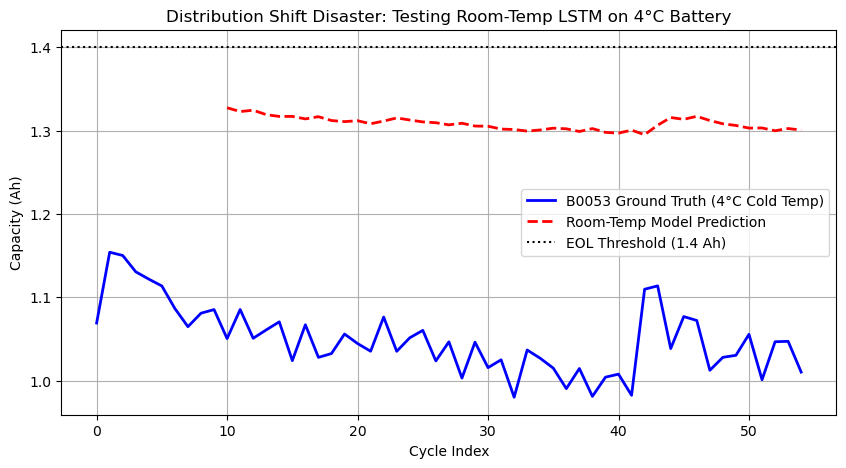

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 1. 重建“室温标尺” (Rebuild Room-Temp Scalers)
# ==========================================
# 我们提取 B0005, B0006, B0007 的数据，重新让机器记住室温的极值
train_ids = ['B0005', 'B0006', 'B0007']
room_temp_features = []

for b_id in train_ids:
    df = room_temp_data[b_id] # 使用刚刚加载的 room_temp_data
    for _, row in df.iterrows():
        try:
            time_arr = row['Time']
            temp_arr = row['Temperature_measured']
            cap = row['Capacity']
            if cap > 0 and len(time_arr) > 0:
                room_temp_features.append([time_arr[-1], np.max(temp_arr), cap])
        except Exception:
            continue
            
room_temp_features = np.array(room_temp_features)

# 重新拟合 (fit) 属于室温的标尺
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
scaler_x.fit(room_temp_features[:, :-1]) # X: 放电时间, 最高温度
scaler_y.fit(room_temp_features[:, -1].reshape(-1, 1)) # Y: 容量

# ==========================================
# 2. 提取 B0053 (4°C) 的物理特征
# ==========================================
df_b0053 = cold_temp_data['B0053']
features_53 = []

for _, row in df_b0053.iterrows():
    try:
        time_arr = row['Time']
        temp_arr = row['Temperature_measured']
        cap = row['Capacity']
        if cap > 0 and len(time_arr) > 0:
            features_53.append([time_arr[-1], np.max(temp_arr), cap])
    except Exception:
        continue
        
features_53 = np.array(features_53)
X_unscaled_53 = features_53[:, :-1]
Y_unscaled_53 = features_53[:, -1].reshape(-1, 1)

# ==========================================
# 3. 分布偏移 (OOD Scaling)
# ==========================================
# 
X_scaled_53 = scaler_x.transform(X_unscaled_53)
Y_scaled_53 = scaler_y.transform(Y_unscaled_53)

# ==========================================
# 4. 构建滑动窗口 & 模型推理
# ==========================================
SEQ_LENGTH = 10
X_test_53, Y_test_53 = [], []

for i in range(len(X_scaled_53) - SEQ_LENGTH):
    X_test_53.append(X_scaled_53[i : i + SEQ_LENGTH])
    Y_test_53.append(Y_scaled_53[i + SEQ_LENGTH])

X_test_tensor_53 = torch.tensor(np.array(X_test_53), dtype=torch.float32)

model.eval()
with torch.no_grad():
    preds_scaled_53 = model(X_test_tensor_53).numpy()

# 反归一化
preds_real_53 = scaler_y.inverse_transform(preds_scaled_53).flatten()
actuals_real_53 = Y_unscaled_53.flatten()

# ==========================================
# 5. 绘制“灾难现场”
# ==========================================
plt.figure(figsize=(10, 5))

# 真实的 4°C 衰减轨迹 (蓝色)
plt.plot(range(len(actuals_real_53)), actuals_real_53, 
         label='B0053 Ground Truth (4°C Cold Temp)', color='blue', linewidth=2)

# 室温模型的瞎猜轨迹 (红色)
predict_x_axis = range(SEQ_LENGTH, len(actuals_real_53))
plt.plot(predict_x_axis, preds_real_53, 
         label='Room-Temp Model Prediction', color='red', linestyle='--', linewidth=2)

plt.axhline(y=1.4, color='black', linestyle=':', label='EOL Threshold (1.4 Ah)')

plt.title('Distribution Shift Disaster: Testing Room-Temp LSTM on 4°C Battery')
plt.xlabel('Cycle Index')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.grid(True)
plt.show()

说明仅仅依靠室温下的模型无法做到对于所有的情况都有良好的认预测，这就是为什么我们需要构建Transformer模型的原因所在。

本部分的代码可能会有些凌乱，我将这一系列的评估流程封装进了BatteryLstm、BatteryDataModule、test_and_plot中，你会在这三个模块中找到答案的。  

### 另一个验证

✅ 自定义 OOP 模块加载成功（已重载）！

>>> [阶段 1] 正在初始化数据引擎与神经网络...
>>> [阶段 2] 封装室温训练集并开始训练...
开始训练模型 (Device: cuda)...
  Epoch [20/100], Loss: 0.005284
  Epoch [40/100], Loss: 0.005220
  Epoch [60/100], Loss: 0.004838
  Epoch [80/100], Loss: 0.004532
  Epoch [100/100], Loss: 0.004290

>>> [阶段 3] 验证同工况泛化能力 (B0018 - 24°C)...


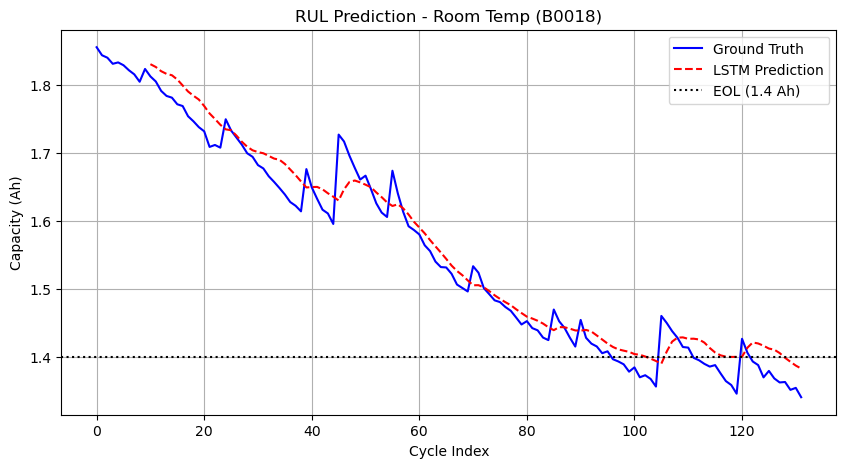


>>> [阶段 4] 揭示物理规律的惩罚：跨工况灾难测试 (B0053 - 4°C)...


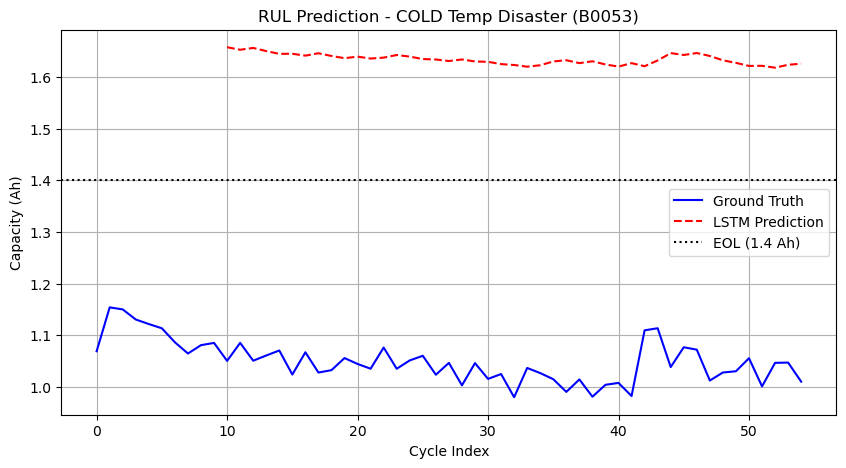

In [5]:
import sys
import torch
import importlib

# 1. 将你的项目根目录加入 Python 寻址路径
PROJECT_ROOT = r"C:\Users\PLUTO\Desktop\battery-rul"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# 2. 强制重载模块，避免 Notebook 缓存旧版本
import src.BatteryLSTM as battery_lstm_module
import utils.BatteryDataModule as battery_data_module
import utils.test_and_plot as test_plot_module
importlib.reload(battery_lstm_module)
importlib.reload(battery_data_module)
importlib.reload(test_plot_module)

# 3. 像调用官方库一样导入你的模块
from src.BatteryLSTM import BatteryLSTM
from utils.BatteryDataModule import BatteryDataModule
from utils.test_and_plot import RULExperiment

print("✅ 自定义 OOP 模块加载成功（已重载）！\n")

# ==========================================
# 实验一：训练室温模型 (B0005, B0006, B0007)
# ==========================================
# 假设 room_temp_data 和 cold_temp_data 依然在你的 Notebook 内存中
print(">>> [阶段 1] 正在初始化数据引擎与神经网络...")
data_engine = BatteryDataModule(seq_length=10, batch_size=16)
model = BatteryLSTM(input_dim=2, hidden_dim=128, num_layers=2)
experiment = RULExperiment(model, data_engine, lr=0.001)

print(">>> [阶段 2] 封装室温训练集并开始训练...")
# 提取 B0005, 06, 07 作为训练字典
train_dict = {k: room_temp_data[k] for k in ['B0005', 'B0006', 'B0007']}
train_loader = data_engine.prepare_train_data(train_dict)

# 启动训练 (训练 100 轮左右即可看清趋势)
experiment.train(train_loader, epochs=100)

# ==========================================
# 实验二：同工况验证 (测试室温下的 B0018)
# ==========================================
print("\n>>> [阶段 3] 验证同工况泛化能力 (B0018 - 24°C)...")
test_loader_18, actual_cap_18 = data_engine.prepare_test_data(room_temp_data['B0018'])
experiment.test_and_plot(test_loader_18, actual_cap_18, title_suffix="- Room Temp (B0018)")

# ==========================================
# 实验三：跨工况“灾难”验证 (测试低温下的 B0053)
# ==========================================
print("\n>>> [阶段 4] 揭示物理规律的惩罚：跨工况灾难测试 (B0053 - 4°C)...")
# 注意：data_engine 内部已经死死锁住了 24°C 的 Scaler
# 我们直接把 4°C 的数据丢进去，看看它会如何崩溃！
test_loader_53, actual_cap_53 = data_engine.prepare_test_data(cold_temp_data['B0053'])
experiment.test_and_plot(test_loader_53, actual_cap_53, title_suffix="- COLD Temp Disaster (B0053)")

## 新版LSTM复现实验（逻辑不变）

说明：本节保留原实验逻辑（室温训练 → 同工况测试 → 跨工况测试），仅将模型替换为 `ClassicLSTMRegressor`。

In [ ]:
import sys
import importlib
import torch

PROJECT_ROOT = r"C:\\Users\\PLUTO\\Desktop\\battery-rul"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# 强制重载，避免Notebook缓存旧版本
import src.LSTM.model as new_lstm_module
import utils.BatteryDataModule as battery_data_module
import utils.test_and_plot as test_plot_module
importlib.reload(new_lstm_module)
importlib.reload(battery_data_module)
importlib.reload(test_plot_module)

from src.LSTM.model import ClassicLSTMRegressor
from utils.BatteryDataModule import BatteryDataModule
from utils.test_and_plot import RULExperiment

# 依赖检查：复用你前面已加载的数据字典
required_vars = ["room_temp_data", "cold_temp_data"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"缺少变量 {missing}，请先运行前面加载数据的单元（室温/低温数据）。")

print("✅ 新版LSTM模块加载成功（已重载）！")
print("\n>>> [阶段 1] 初始化数据引擎与新版LSTM网络...")
data_engine = BatteryDataModule(seq_length=10, batch_size=16)
model = ClassicLSTMRegressor(input_dim=2, hidden_dim=128, num_layers=2, dropout=0.1)
experiment = RULExperiment(model, data_engine, lr=0.001)

print(">>> [阶段 2] 室温训练集训练 (B0005, B0006, B0007)...")
train_dict = {k: room_temp_data[k] for k in ['B0005', 'B0006', 'B0007']}
train_loader = data_engine.prepare_train_data(train_dict)
experiment.train(train_loader, epochs=100)

print("\n>>> [阶段 3] 同工况泛化验证 (B0018 - 24°C)...")
test_loader_18, actual_cap_18 = data_engine.prepare_test_data(room_temp_data['B0018'])
experiment.test_and_plot(test_loader_18, actual_cap_18, title_suffix="- Room Temp (B0018) [ClassicLSTM]")

print("\n>>> [阶段 4] 跨工况测试 (B0053 - 4°C)...")
test_loader_53, actual_cap_53 = data_engine.prepare_test_data(cold_temp_data['B0053'])
experiment.test_and_plot(test_loader_53, actual_cap_53, title_suffix="- COLD Temp (B0053) [ClassicLSTM]")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("\n====== 新版LSTM量化评估（B0018） ======")
model.eval()
preds_18 = []
with torch.no_grad():
    for batch_x, _ in test_loader_18:
        batch_x = batch_x.to(experiment.device)
        out = model(batch_x)
        preds_18.append(out.cpu().item())

preds_18_real = data_engine.scaler_y.inverse_transform(np.array(preds_18).reshape(-1, 1)).flatten()
y_true_18 = actual_cap_18[data_engine.seq_length:]
rmse_18 = np.sqrt(mean_squared_error(y_true_18, preds_18_real))
mae_18 = mean_absolute_error(y_true_18, preds_18_real)
mape_18 = np.mean(np.abs((y_true_18 - preds_18_real) / np.clip(y_true_18, 1e-8, None))) * 100

print(f"RMSE: {rmse_18:.4f} Ah")
print(f"MAE : {mae_18:.4f} Ah")
print(f"MAPE: {mape_18:.2f}%")

print("\n====== 新版LSTM量化评估（B0053，跨工况） ======")
preds_53 = []
with torch.no_grad():
    for batch_x, _ in test_loader_53:
        batch_x = batch_x.to(experiment.device)
        out = model(batch_x)
        preds_53.append(out.cpu().item())

preds_53_real = data_engine.scaler_y.inverse_transform(np.array(preds_53).reshape(-1, 1)).flatten()
y_true_53 = actual_cap_53[data_engine.seq_length:]
rmse_53 = np.sqrt(mean_squared_error(y_true_53, preds_53_real))
mae_53 = mean_absolute_error(y_true_53, preds_53_real)
mape_53 = np.mean(np.abs((y_true_53 - preds_53_real) / np.clip(y_true_53, 1e-8, None))) * 100

print(f"RMSE: {rmse_53:.4f} Ah")
print(f"MAE : {mae_53:.4f} Ah")
print(f"MAPE: {mape_53:.2f}%")

## 论文对比图：为什么不采用“前70%预测后30%”作为主评估

目的：在**同一模型（ClassicLSTMRegressor）**下，统一绘图逻辑对比三种场景：
1. 单电池时间切分（B0005，前70%训练后30%测试）
2. 同工况跨电池（训练B0005/6/7，测试B0018）
3. 跨工况测试（训练24°C，测试4°C的B0053）

该对比可直观说明：前70/30更像“同一电池的短期外推”，难度较低，不足以代表真实部署的泛化挑战。

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------- 工具函数：评估一个测试loader并反归一化 ----------
def _predict_with_loader(exp_obj, model_obj, test_loader, scaler_y):
    model_obj.eval()
    preds_scaled = []
    y_scaled = []
    with torch.no_grad():
        for bx, by in test_loader:
            bx = bx.to(exp_obj.device)
            out = model_obj(bx)
            preds_scaled.append(out.cpu().item())
            y_scaled.append(by.item())
    preds_real = scaler_y.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    y_real = scaler_y.inverse_transform(np.array(y_scaled).reshape(-1, 1)).flatten()
    return y_real, preds_real

# ---------- A) 单电池时间切分：B0005 前70%/后30% ----------
train_loader_b5, test_loader_b5, scaler_y_b5 = build_lstm_dataloader(
    room_temp_data['B0005'], seq_length=10, train_ratio=0.7, batch_size=16
)

single_model = ClassicLSTMRegressor(input_dim=2, hidden_dim=128, num_layers=2, dropout=0.1)
single_exp = RULExperiment(single_model, BatteryDataModule(seq_length=10, batch_size=16), lr=0.001)
single_exp.train(train_loader_b5, epochs=100)
y_true_b5, preds_b5_real = _predict_with_loader(single_exp, single_model, test_loader_b5, scaler_y_b5)

# ---------- B/C) 尽量复用现有结果；若不存在则自动重算 ----------
# 需要变量：data_engine, room_temp_data, low_temp_data, actual_cap_18, actual_cap_53
need_recompute_bc = any(name not in globals() for name in [
    'data_engine', 'room_temp_data', 'low_temp_data', 'actual_cap_18', 'actual_cap_53', 'preds_18', 'preds_53'
 ])

if need_recompute_bc:
    # 训练集（室温）
    train_keys = ['B0005', 'B0006', 'B0007']
    train_dfs = [room_temp_data[k] for k in train_keys]

    data_engine = BatteryDataModule(seq_length=10, batch_size=16)
    X_train, y_train = data_engine.create_sequences(train_dfs[0])
    for df in train_dfs[1:]:
        Xi, yi = data_engine.create_sequences(df)
        X_train = np.concatenate([X_train, Xi], axis=0)
        y_train = np.concatenate([y_train, yi], axis=0)

    X_train_s, y_train_s = data_engine.fit_transform(X_train, y_train)
    X_train_t = torch.FloatTensor(X_train_s)
    y_train_t = torch.FloatTensor(y_train_s)
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train_t, y_train_t),
        batch_size=16, shuffle=True
    )

    # 使用同规格ClassicLSTM训练主模型
    base_model = ClassicLSTMRegressor(input_dim=2, hidden_dim=128, num_layers=2, dropout=0.1)
    base_exp = RULExperiment(base_model, data_engine, lr=0.001)
    base_exp.train(train_loader, epochs=100)

    # 同工况跨电池 B0018
    X18, y18 = data_engine.create_sequences(room_temp_data['B0018'])
    X18_s = data_engine.scaler_X.transform(X18.reshape(-1, 2)).reshape(X18.shape)
    y18_s = data_engine.scaler_y.transform(y18.reshape(-1, 1)).flatten()
    test_loader_18 = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.FloatTensor(X18_s), torch.FloatTensor(y18_s)),
        batch_size=1, shuffle=False
    )
    y_true_18, preds_18_real = _predict_with_loader(base_exp, base_model, test_loader_18, data_engine.scaler_y)

    # 跨工况 B0053
    X53, y53 = data_engine.create_sequences(low_temp_data['B0053'])
    X53_s = data_engine.scaler_X.transform(X53.reshape(-1, 2)).reshape(X53.shape)
    y53_s = data_engine.scaler_y.transform(y53.reshape(-1, 1)).flatten()
    test_loader_53 = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.FloatTensor(X53_s), torch.FloatTensor(y53_s)),
        batch_size=1, shuffle=False
    )
    y_true_53, preds_53_real = _predict_with_loader(base_exp, base_model, test_loader_53, data_engine.scaler_y)
else:
    preds_18_real = data_engine.scaler_y.inverse_transform(np.array(preds_18).reshape(-1, 1)).flatten()
    y_true_18 = actual_cap_18[data_engine.seq_length:]
    preds_53_real = data_engine.scaler_y.inverse_transform(np.array(preds_53).reshape(-1, 1)).flatten()
    y_true_53 = actual_cap_53[data_engine.seq_length:]

# ---------- 统一绘图逻辑（论文可用） ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图1：单电池 70/30
axes[0].plot(y_true_b5, label='Ground Truth', color='blue')
axes[0].plot(preds_b5_real, label='Prediction', color='red', linestyle='--')
axes[0].axhline(y=1.4, color='black', linestyle=':', label='EOL=1.4Ah')
axes[0].set_title('A) Single Battery Split (B0005: 70/30)')
axes[0].set_xlabel('Test Cycle Index')
axes[0].set_ylabel('Capacity (Ah)')
axes[0].grid(True)
axes[0].legend(fontsize=8)

# 图2：同工况跨电池
x2 = np.arange(10, 10 + len(y_true_18))
axes[1].plot(x2, y_true_18, label='Ground Truth', color='blue')
axes[1].plot(x2, preds_18_real, label='Prediction', color='red', linestyle='--')
axes[1].axhline(y=1.4, color='black', linestyle=':')
axes[1].set_title('B) Inter-Battery (Train: B0005/6/7, Test: B0018)')
axes[1].set_xlabel('Cycle Index')
axes[1].set_ylabel('Capacity (Ah)')
axes[1].grid(True)
axes[1].legend(fontsize=8)

# 图3：跨工况
x3 = np.arange(10, 10 + len(y_true_53))
axes[2].plot(x3, y_true_53, label='Ground Truth', color='blue')
axes[2].plot(x3, preds_53_real, label='Prediction', color='red', linestyle='--')
axes[2].axhline(y=1.4, color='black', linestyle=':')
axes[2].set_title('C) Cross-Condition (Train: 24°C, Test: 4°C B0053)')
axes[2].set_xlabel('Cycle Index')
axes[2].set_ylabel('Capacity (Ah)')
axes[2].grid(True)
axes[2].legend(fontsize=8)

plt.suptitle('ClassicLSTM Comparison: Why 70/30 Split Is Not Sufficient as Main Evaluation', fontsize=13)
plt.tight_layout()
plt.show()